# SAFE: Exploratory Data Analysis for DSS Question 1

## Purpose

This notebook addresses **DSS Question 1 (Descriptive)** and uses the resulting insights to motivate Questions 2 and 3.

- **Q1(a)** What proportion of ICU patients are flagged at risk of sepsis? What demographic and clinical patterns exist?
- **Q1(b)** How does clinical response vary by patient characteristics? *Note: PhysioNet 2019 lacks explicit response variables (notification times, treatment orders). We use time-to-sepsis-onset and ICU length of stay as proxies for response opportunity windows.*
- **Q1(c)** What are the most common combinations of clinical variables that trigger alerts?

## Setup and data loading

In [2]:
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Color palette aligned with SAFE's tiered alert design
RISK_COLORS = {'Low': '#2ca02c', 'Moderate': '#ff7f0e', 'High': '#d62728'}
SEPSIS_COLORS = {0: '#1f77b4', 1: '#d62728'}

In [3]:
# Load the preprocessed PhysioNet dataset
df = pd.read_csv('C:\\Users\\imama\\Documents\\GitHub\\safe_dss\\preprocessing\\balanced_patient_data.csv')
df.columns = [c.lower() for c in df.columns]

print(f'Hourly records: {len(df):,}')
print(f'Unique patients: {df["patient_id"].nunique():,}')
print(f'Columns: {df.shape[1]}')
df.head()

Hourly records: 171,736
Unique patients: 3,580
Columns: 42


,hr,o2sat,temp,sbp,map,dbp,resp,etco2,baseexcess,hco3,fio2,ph,paco2,sao2,ast,bun,alkalinephos,calcium,chloride,creatinine,bilirubin_direct,glucose,lactate,magnesium,phosphate,potassium,bilirubin_total,troponini,hct,hgb,ptt,wbc,fibrinogen,platelets,age,gender,unit1,unit2,hospadmtime,iculos,sepsislabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.71,0,0.0,1.0,-8.77,1,0,p000004
1,103.5,97.0,NaN,107.5,70.5,52.0,18.0,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,14.0,NaN,NaN,105.0,0.8,NaN,NaN,NaN,1.7,NaN,NaN,NaN,NaN,27.6,NaN,21.3,NaN,NaN,220.0,65.71,0,0.0,1.0,-8.77,2,0,p000004
2,108.0,98.5,36.78,124.5,82.0,61.5,19.5,NaN,0.0,NaN,NaN,7.36,45.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,253.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.71,0,0.0,1.0,-8.77,3,0,p000004
3,107.5,96.5,NaN,117.5,77.5,58.5,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.71,0,0.0,1.0,-8.77,4,0,p000004
4,113.0,100.0,NaN,125.0,80.0,61.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.71,0,0.0,1.0,-8.77,5,0,p000004


---
## Section 1: Establish a proxy risk flagging rule

We use published Sepsis-3, qSOFA, and SIRS aligned thresholds to define a **proxy risk flag** for descriptive analysis. This lets us answer Q1(a) ("what proportion are flagged") without circular reasoning against the true sepsis label.

**Risk criteria per hourly record** (any one triggers a flag):
- Lactate > 2.0 mmol/L (tissue hypoperfusion)
- MAP < 65 mmHg (hypotension)
- Heart rate > 100 bpm (tachycardia)
- Respiratory rate > 22 (qSOFA criterion)
- WBC < 4 or > 12 x10^9/L (abnormal leukocyte count)
- Temperature < 36 or > 38 deg C (SIRS criterion)

**Tier assignment** matches SAFE's tiered alert design:
- 0 criteria -> Low
- 1-2 criteria -> Moderate
- 3+ criteria -> High

In [4]:
df['c_lactate'] = (df['lactate'] > 2.0).astype(int)
df['c_map'] = (df['map'] < 65).astype(int)
df['c_hr'] = (df['hr'] > 100).astype(int)
df['c_resp'] = (df['resp'] > 22).astype(int)
df['c_wbc'] = ((df['wbc'] < 4) | (df['wbc'] > 12)).astype(int)
df['c_temp'] = ((df['temp'] < 36) | (df['temp'] > 38)).astype(int)

criteria_cols = ['c_lactate', 'c_map', 'c_hr', 'c_resp', 'c_wbc', 'c_temp']
df['n_criteria'] = df[criteria_cols].sum(axis=1)
df['flagged'] = (df['n_criteria'] >= 1).astype(int)
df['risk_tier'] = pd.cut(df['n_criteria'], bins=[-1, 0, 2, 10],
                         labels=['Low', 'Moderate', 'High'])

print('Hourly record tier distribution:')
print(df['risk_tier'].value_counts(normalize=True).round(3))

Hourly record tier distribution:
risk_tier
Low         0.495
Moderate    0.478
High        0.027
Name: proportion, dtype: float64


### Patient-level rollup

For demographic analysis, we collapse hourly data into one row per patient, recording the maximum tier reached, total flagged hours, and time to first sepsis label.

In [5]:
summary = df.groupby('patient_id').agg(
    age=('age', 'first'),
    gender=('gender', 'first'),
    unit1=('unit1', 'first'),
    unit2=('unit2', 'first'),
    icu_los_max=('iculos', 'max'),
    ever_flagged=('flagged', 'max'),
    max_n_criteria=('n_criteria', 'max'),
    hours_flagged=('flagged', 'sum'),
    sepsis_label=('sepsislabel', 'max'),
).reset_index()

summary['max_tier'] = pd.cut(summary['max_n_criteria'], bins=[-1, 0, 2, 10],
                             labels=['Low', 'Moderate', 'High'])
summary['age_group'] = pd.cut(summary['age'], bins=[0, 40, 55, 70, 85, 120],
                              labels=['<40', '40-55', '55-70', '70-85', '85+'])
summary['gender_label'] = summary['gender'].map({0: 'Female', 1: 'Male'})

# Time to first sepsis label (proxy for response window)
sepsis_only = df[df['sepsislabel'] == 1].groupby('patient_id')['iculos'].min()
summary['first_sepsis_hour'] = summary['patient_id'].map(sepsis_only)

summary.head()

,patient_id,age,gender,unit1,unit2,icu_los_max,ever_flagged,max_n_criteria,hours_flagged,sepsis_label,max_tier,age_group,gender_label,first_sepsis_hour
0,p000004,65.71,0,0.0,1.0,29,1,2,20,0,Moderate,55-70,Female,NaN
1,p000009,27.92,1,NaN,NaN,258,1,4,227,1,High,<40,Male,249.0
2,p000011,65.79,1,NaN,NaN,35,1,1,6,1,Moderate,55-70,Male,26.0
3,p000015,58.54,0,NaN,NaN,15,1,1,2,1,Moderate,55-70,Female,6.0
4,p000018,39.28,1,1.0,0.0,134,1,3,96,1,High,<40,Male,126.0


---
## Section 2: DSS Q1(a) - Proportion flagged and demographic patterns

In [6]:
n = len(summary)
n_flagged = summary['ever_flagged'].sum()

print(f'Total ICU patients: {n:,}')
print(f'Ever flagged: {n_flagged:,} ({n_flagged/n*100:.1f}%)')
print()
print('Maximum risk tier reached during stay:')
tier_counts = summary['max_tier'].value_counts().reindex(['Low', 'Moderate', 'High'])
for tier, count in tier_counts.items():
    print(f'  {tier:9s}: {count:>5,} ({count/n*100:5.1f}%)')

Total ICU patients: 3,580
Ever flagged: 3,522 (98.4%)

Maximum risk tier reached during stay:
  Low      :    58 (  1.6%)
  Moderate : 2,292 ( 64.0%)
  High     : 1,230 ( 34.4%)


### Figure 1: Overall flag distribution

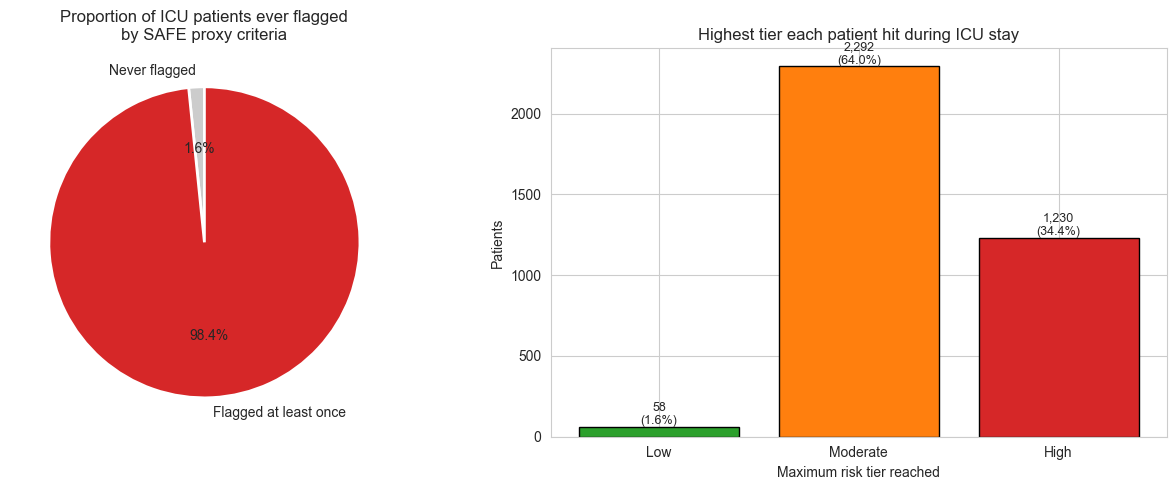

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

flagged_counts = summary['ever_flagged'].value_counts().sort_index()
axes[0].pie(flagged_counts, labels=['Never flagged', 'Flagged at least once'],
            autopct='%1.1f%%', colors=['#cccccc', '#d62728'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proportion of ICU patients ever flagged\nby SAFE proxy criteria')

bars = axes[1].bar(tier_counts.index.astype(str), tier_counts.values,
                   color=[RISK_COLORS[t] for t in tier_counts.index.astype(str)],
                   edgecolor='black')
axes[1].set_ylabel('Patients')
axes[1].set_xlabel('Maximum risk tier reached')
axes[1].set_title('Highest tier each patient hit during ICU stay')
for bar, count in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + n*0.005,
                 f'{count:,}\n({count/n*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Figure 2: Flag rate by demographics

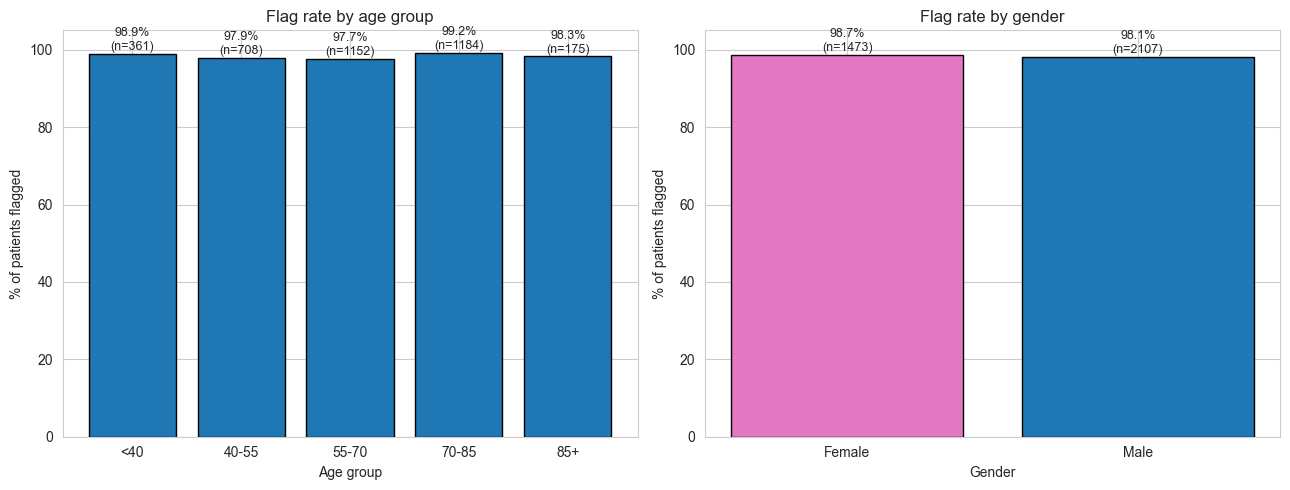


Chi-square (age vs flagged):    chi2=10.99, p=0.02672
Chi-square (gender vs flagged): chi2=1.38, p=0.2404


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_flag = (summary.groupby('age_group', observed=True)['ever_flagged']
            .agg(['mean', 'count']))
age_flag['pct'] = age_flag['mean'] * 100
bars = axes[0].bar(age_flag.index.astype(str), age_flag['pct'],
                   color='#1f77b4', edgecolor='black')
axes[0].set_ylabel('% of patients flagged')
axes[0].set_xlabel('Age group')
axes[0].set_title('Flag rate by age group')
axes[0].set_ylim(0, 105)
for bar, pct, n_grp in zip(bars, age_flag['pct'], age_flag['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%\n(n={n_grp})', ha='center', fontsize=9)

gender_flag = (summary.groupby('gender_label')['ever_flagged']
               .agg(['mean', 'count']))
gender_flag['pct'] = gender_flag['mean'] * 100
bars = axes[1].bar(gender_flag.index, gender_flag['pct'],
                   color=['#e377c2', '#1f77b4'], edgecolor='black')
axes[1].set_ylabel('% of patients flagged')
axes[1].set_xlabel('Gender')
axes[1].set_title('Flag rate by gender')
axes[1].set_ylim(0, 105)
for bar, pct, n_grp in zip(bars, gender_flag['pct'], gender_flag['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%\n(n={n_grp})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Chi-square tests
contingency_age = pd.crosstab(summary['age_group'], summary['ever_flagged'])
chi2_a, p_a, _, _ = stats.chi2_contingency(contingency_age)
print(f'\nChi-square (age vs flagged):    chi2={chi2_a:.2f}, p={p_a:.4g}')

contingency_g = pd.crosstab(summary['gender_label'], summary['ever_flagged'])
chi2_g, p_g, _, _ = stats.chi2_contingency(contingency_g)
print(f'Chi-square (gender vs flagged): chi2={chi2_g:.2f}, p={p_g:.4g}')

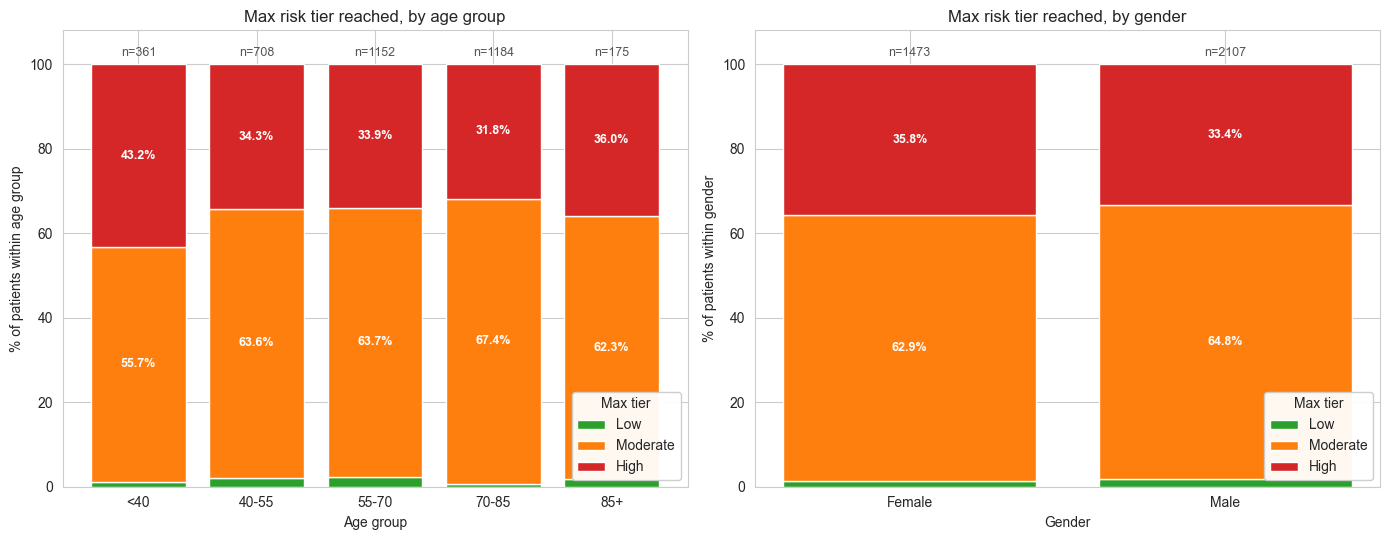


Chi-square (age group vs max tier):  chi2=27.58, p=0.0005604
Chi-square (gender vs max tier):     chi2=3.62, p=0.1639


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
tier_order = ['Low', 'Moderate', 'High']

# Left: max tier composition by age group
age_tier = (pd.crosstab(summary['age_group'], summary['max_tier'],
                        normalize='index') * 100)[tier_order]
age_counts = summary['age_group'].value_counts().reindex(age_tier.index)

bottom = np.zeros(len(age_tier))
for tier in tier_order:
    axes[0].bar(age_tier.index.astype(str), age_tier[tier], bottom=bottom,
                color=RISK_COLORS[tier], edgecolor='white', label=tier)
    for i, val in enumerate(age_tier[tier].values):
        if val >= 3:
            axes[0].text(i, bottom[i] + val/2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold')
    bottom += age_tier[tier].values

for i, count in enumerate(age_counts.values):
    axes[0].text(i, 102, f'n={count}', ha='center', fontsize=9, color='#555')

axes[0].set_ylabel('% of patients within age group')
axes[0].set_xlabel('Age group')
axes[0].set_title('Max risk tier reached, by age group')
axes[0].set_ylim(0, 108)
axes[0].legend(title='Max tier', loc='lower right', framealpha=0.95)

# Right: max tier composition by gender
gender_tier = (pd.crosstab(summary['gender_label'], summary['max_tier'],
                           normalize='index') * 100)[tier_order]
gender_counts = summary['gender_label'].value_counts().reindex(gender_tier.index)

bottom = np.zeros(len(gender_tier))
for tier in tier_order:
    axes[1].bar(gender_tier.index, gender_tier[tier], bottom=bottom,
                color=RISK_COLORS[tier], edgecolor='white', label=tier)
    for i, val in enumerate(gender_tier[tier].values):
        if val >= 3:
            axes[1].text(i, bottom[i] + val/2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold')
    bottom += gender_tier[tier].values

for i, count in enumerate(gender_counts.values):
    axes[1].text(i, 102, f'n={count}', ha='center', fontsize=9, color='#555')

axes[1].set_ylabel('% of patients within gender')
axes[1].set_xlabel('Gender')
axes[1].set_title('Max risk tier reached, by gender')
axes[1].set_ylim(0, 108)
axes[1].legend(title='Max tier', loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.show()

# Chi-square tests
age_contingency = pd.crosstab(summary['age_group'], summary['max_tier'])
chi2_a, p_a, _, _ = stats.chi2_contingency(age_contingency)
print(f'\nChi-square (age group vs max tier):  chi2={chi2_a:.2f}, p={p_a:.4g}')

gender_contingency = pd.crosstab(summary['gender_label'], summary['max_tier'])
chi2_g, p_g, _, _ = stats.chi2_contingency(gender_contingency)
print(f'Chi-square (gender vs max tier):     chi2={chi2_g:.2f}, p={p_g:.4g}')

### Figure 3: Distribution of key clinical variables by sepsis label

We compare hourly distributions of six Sepsis-3 / qSOFA relevant variables between sepsis-positive and sepsis-negative hours. Distributions overlap substantially but show meaningful median shifts, confirming that no single variable is sufficient for detection and motivating a multivariate model.

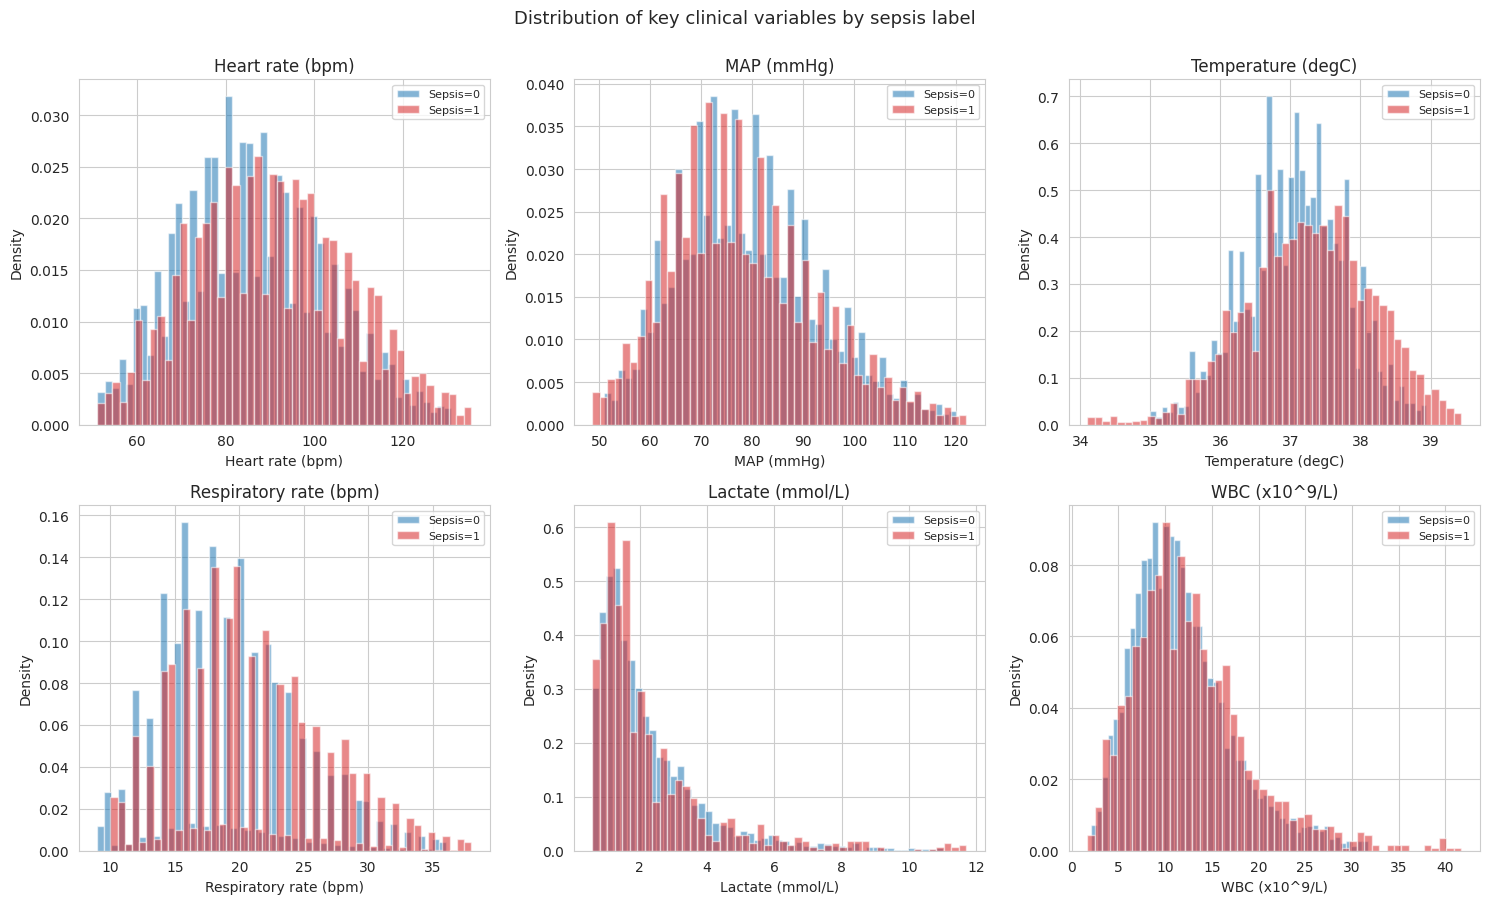


Mann-Whitney U tests (sepsis-positive vs sepsis-negative hours):
  hr        : median pos=89.50, median neg=85.00, p=9.90e-157


  map       : median pos=76.00, median neg=78.00, p=6.37e-32
  temp      : median pos=37.30, median neg=37.10, p=4.59e-60


  resp      : median pos=20.00, median neg=19.00, p=1.70e-169
  lactate   : median pos=1.70, median neg=1.80, p=1.42e-02


  wbc       : median pos=11.70, median neg=10.90, p=1.20e-06


In [8]:
key_vars = ['hr', 'map', 'temp', 'resp', 'lactate', 'wbc']
var_labels = {'hr': 'Heart rate (bpm)', 'map': 'MAP (mmHg)',
              'temp': 'Temperature (degC)', 'resp': 'Respiratory rate (bpm)',
              'lactate': 'Lactate (mmol/L)', 'wbc': 'WBC (x10^9/L)'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, var in zip(axes.flat, key_vars):
    for label, color in SEPSIS_COLORS.items():
        subset = df[df['sepsislabel'] == label][var].dropna()
        q01, q99 = subset.quantile([0.01, 0.99])
        subset = subset[(subset >= q01) & (subset <= q99)]
        ax.hist(subset, bins=50, alpha=0.55, color=color,
                label=f'Sepsis={label}', density=True)
    ax.set_xlabel(var_labels[var])
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_title(var_labels[var])

plt.suptitle('Distribution of key clinical variables by sepsis label',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

print('\nMann-Whitney U tests (sepsis-positive vs sepsis-negative hours):')
for var in key_vars:
    pos = df[df['sepsislabel'] == 1][var].dropna()
    neg = df[df['sepsislabel'] == 0][var].dropna()
    u, p = stats.mannwhitneyu(pos, neg, alternative='two-sided')
    print(f'  {var:10s}: median pos={pos.median():.2f}, '
          f'median neg={neg.median():.2f}, p={p:.2e}')

---
## Section 3: DSS Q1(b) — Response opportunity proxies by patient characteristics

**Important limitation:** PhysioNet 2019 does not include physician notification, diagnostic test orders, or treatment initiation timestamps. A direct answer to "how does clinical response vary" is not possible with this dataset. We use three proxies for response opportunity:

- **First sepsis hour** — how early sepsis appeared in the ICU stay (earlier onset = shorter intervention window)
- **Hours flagged** — how many times the patient triggered criteria (opportunities for notification)
- **ICU length of stay** — total observation window

In [9]:
septic = summary[summary['sepsis_label'] == 1].copy()

print(f'Septic patient cohort: {len(septic):,} patients')
print(f'Median first-sepsis hour:   {septic["first_sepsis_hour"].median():.1f}')
print(f'Median hours flagged:       {septic["hours_flagged"].median():.1f}')
print(f'Median ICU LOS:             {summary["icu_los_max"].median():.1f}')

Septic patient cohort: 1,790 patients
Median first-sepsis hour:   29.5
Median hours flagged:       19.0
Median ICU LOS:             40.0


### Figure 4: Response proxies across demographics and risk tiers

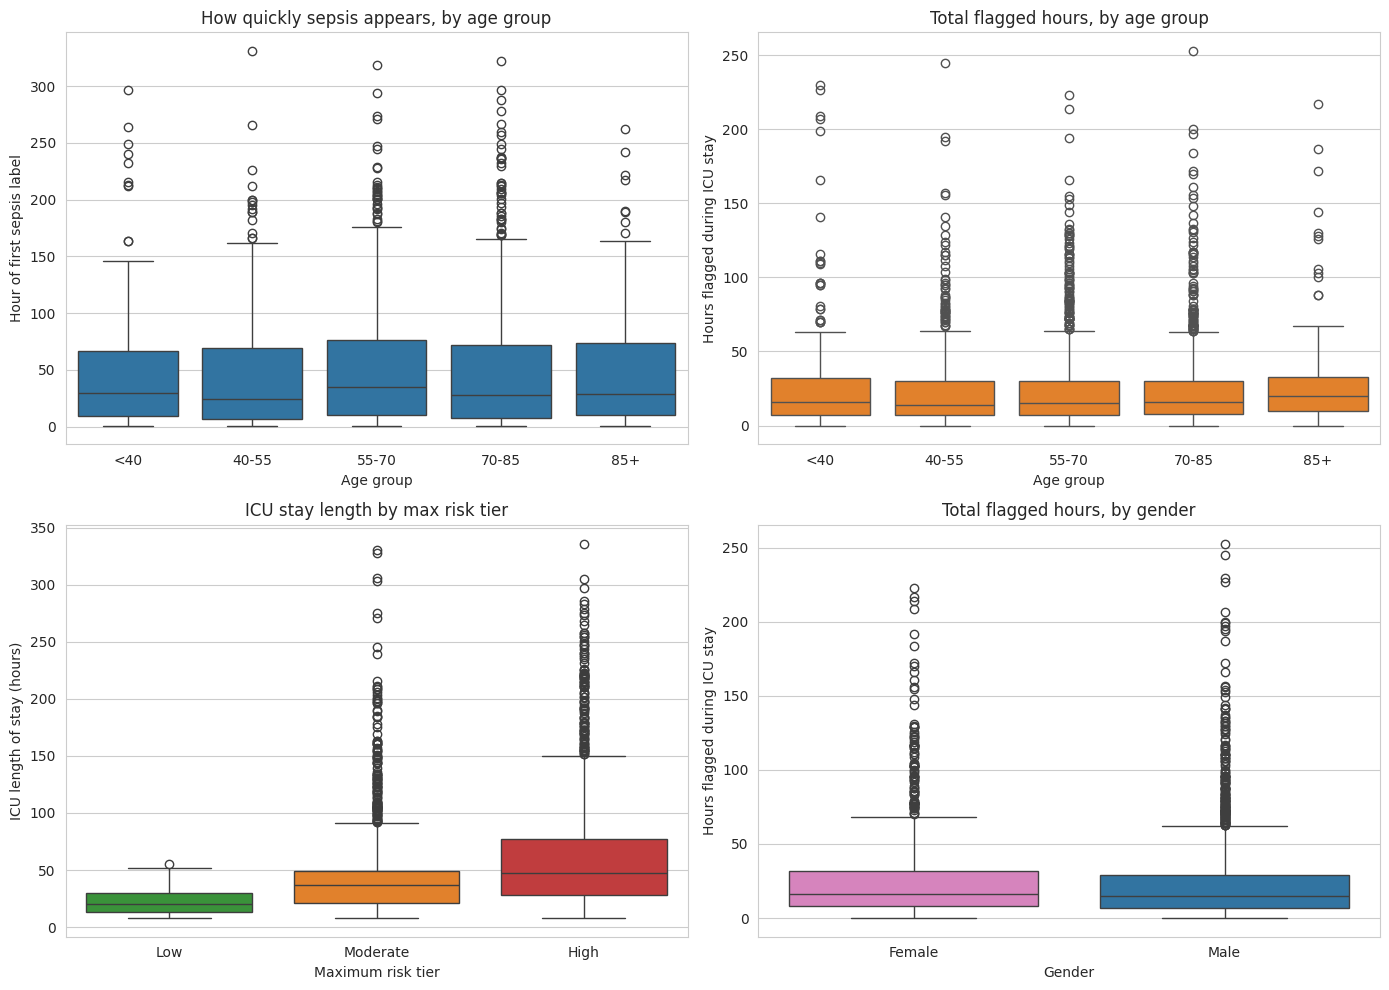


Kruskal-Wallis: first_sepsis_hour across age groups
  H=7.64, p=0.1056

Kruskal-Wallis: hours_flagged across max tier groups
  H=1016.72, p=1.671e-221


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

septic_clean = septic.dropna(subset=['age_group', 'first_sepsis_hour'])
sns.boxplot(data=septic_clean, x='age_group', y='first_sepsis_hour',
            ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_ylabel('Hour of first sepsis label')
axes[0, 0].set_xlabel('Age group')
axes[0, 0].set_title('How quickly sepsis appears, by age group')

sns.boxplot(data=summary.dropna(subset=['age_group']),
            x='age_group', y='hours_flagged',
            ax=axes[0, 1], color='#ff7f0e')
axes[0, 1].set_ylabel('Hours flagged during ICU stay')
axes[0, 1].set_xlabel('Age group')
axes[0, 1].set_title('Total flagged hours, by age group')

sns.boxplot(data=summary, x='max_tier', y='icu_los_max',
            ax=axes[1, 0], order=['Low', 'Moderate', 'High'],
            palette=[RISK_COLORS[t] for t in ['Low', 'Moderate', 'High']])
axes[1, 0].set_ylabel('ICU length of stay (hours)')
axes[1, 0].set_xlabel('Maximum risk tier')
axes[1, 0].set_title('ICU stay length by max risk tier')

sns.boxplot(data=summary.dropna(subset=['gender_label']),
            x='gender_label', y='hours_flagged',
            ax=axes[1, 1], palette=['#e377c2', '#1f77b4'])
axes[1, 1].set_ylabel('Hours flagged during ICU stay')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_title('Total flagged hours, by gender')

plt.tight_layout()
plt.show()

# Kruskal-Wallis tests
print('\nKruskal-Wallis: first_sepsis_hour across age groups')
groups = [g['first_sepsis_hour'].dropna().values
          for _, g in septic.groupby('age_group', observed=True)]
groups = [g for g in groups if len(g) > 0]
if len(groups) > 1:
    h, p = stats.kruskal(*groups)
    print(f'  H={h:.2f}, p={p:.4g}')

print('\nKruskal-Wallis: hours_flagged across max tier groups')
tier_groups = [g['hours_flagged'].values
               for _, g in summary.groupby('max_tier', observed=True)]
tier_groups = [g for g in tier_groups if len(g) > 0]
if len(tier_groups) > 1:
    h, p = stats.kruskal(*tier_groups)
    print(f'  H={h:.2f}, p={p:.4g}')

---
## Section 4: DSS Q1(c) - Most common trigger combinations

This is the most actionable section for SAFE's alert design: knowing which combinations of abnormalities most often co-occur tells us which phenotypes the model needs to distinguish and which combinations deserve high-tier alerts.

In [11]:
criteria_labels = {
    'c_lactate': 'Lactate>2',
    'c_map': 'MAP<65',
    'c_hr': 'HR>100',
    'c_resp': 'Resp>22',
    'c_wbc': 'WBC abn',
    'c_temp': 'Temp abn',
}

flagged_hours = df[df['flagged'] == 1]
print(f'Flagged hourly records: {len(flagged_hours):,} of {len(df):,} '
      f'({len(flagged_hours)/len(df)*100:.1f}%)')

print('\nIndividual criterion trigger rate (across flagged hours):')
for c in criteria_cols:
    rate = flagged_hours[c].mean() * 100
    print(f'  {criteria_labels[c]:12s}: {rate:5.1f}%')

Flagged hourly records: 86,732 of 171,736 (50.5%)

Individual criterion trigger rate (across flagged hours):
  Lactate>2   :   4.0%
  MAP<65      :  27.2%
  HR>100      :  39.7%
  Resp>22     :  47.6%
  WBC abn     :   7.1%
  Temp abn    :  12.0%


### Figure 5: Single-criterion frequency and co-occurrence heatmap

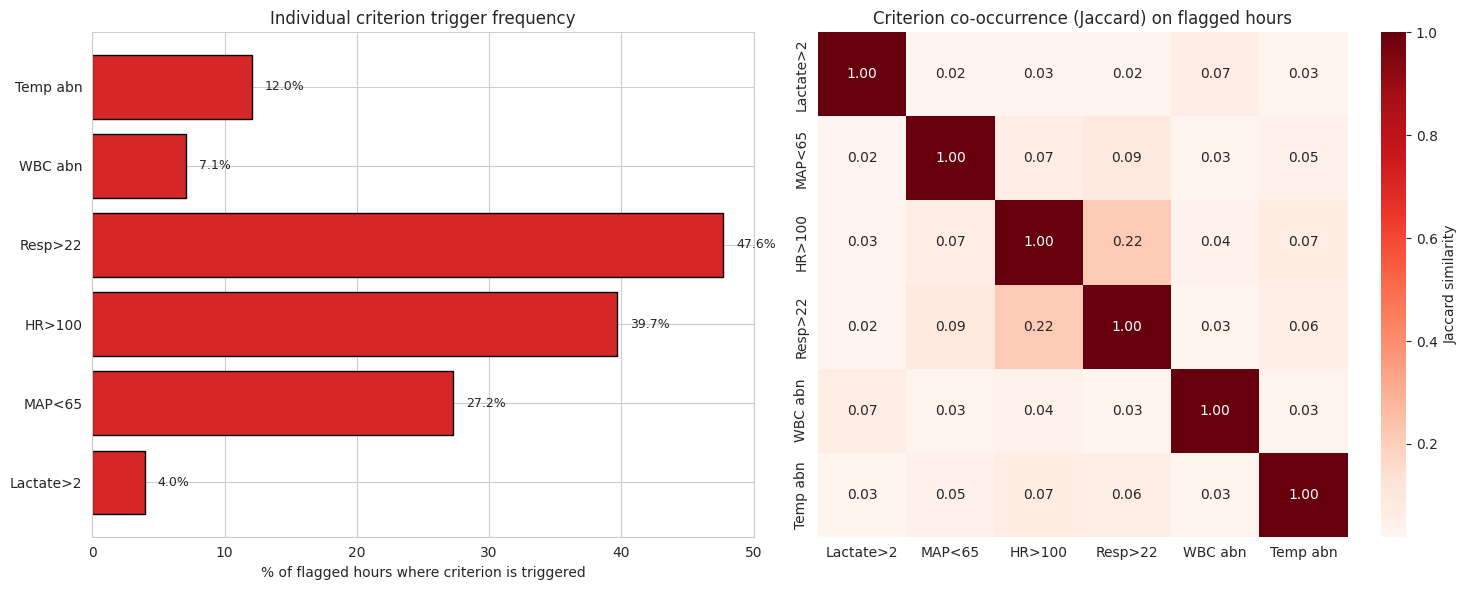

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rates = [flagged_hours[c].mean() * 100 for c in criteria_cols]
bars = axes[0].barh([criteria_labels[c] for c in criteria_cols], rates,
                    color='#d62728', edgecolor='black')
axes[0].set_xlabel('% of flagged hours where criterion is triggered')
axes[0].set_title('Individual criterion trigger frequency')
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontsize=9)

# Jaccard co-occurrence
n_crit = len(criteria_cols)
cooc = np.zeros((n_crit, n_crit))
for i, ci in enumerate(criteria_cols):
    for j, cj in enumerate(criteria_cols):
        both = ((flagged_hours[ci] == 1) & (flagged_hours[cj] == 1)).sum()
        either = ((flagged_hours[ci] == 1) | (flagged_hours[cj] == 1)).sum()
        cooc[i, j] = both / either if either > 0 else 0

sns.heatmap(cooc,
            xticklabels=[criteria_labels[c] for c in criteria_cols],
            yticklabels=[criteria_labels[c] for c in criteria_cols],
            annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
            cbar_kws={'label': 'Jaccard similarity'})
axes[1].set_title('Criterion co-occurrence (Jaccard) on flagged hours')

plt.tight_layout()
plt.show()

### Figure 6: Top 15 most common trigger combinations

Top 15 trigger combinations (out of 63 unique patterns):
  Resp>22                                           : 21,334 ( 24.6%)
  HR>100                                            : 15,794 ( 18.2%)
  MAP<65                                            : 13,987 ( 16.1%)
  HR>100 + Resp>22                                  : 10,281 ( 11.9%)
  Temp abn                                          :  4,229 (  4.9%)
  MAP<65 + Resp>22                                  :  3,545 (  4.1%)
  WBC abn                                           :  2,607 (  3.0%)
  MAP<65 + HR>100                                   :  2,106 (  2.4%)
  HR>100 + Temp abn                                 :  1,496 (  1.7%)
  Resp>22 + Temp abn                                :  1,448 (  1.7%)
  Lactate>2                                         :  1,219 (  1.4%)
  MAP<65 + HR>100 + Resp>22                         :  1,129 (  1.3%)
  HR>100 + Resp>22 + Temp abn                       :  1,093 (  1.3%)
  MAP<65 + Temp abn              

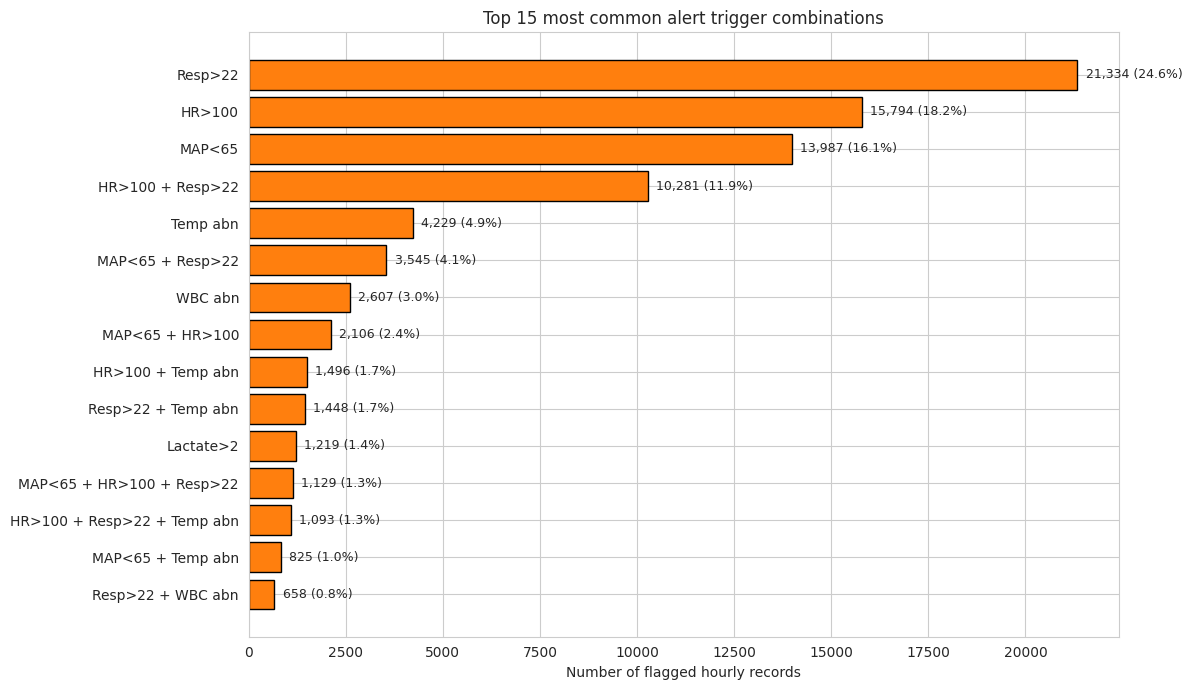

In [13]:
combo_counter = Counter()
for _, row in flagged_hours[criteria_cols].iterrows():
    triggered = tuple(criteria_labels[c] for c in criteria_cols if row[c] == 1)
    combo_counter[triggered] += 1

top_combos = combo_counter.most_common(15)
print(f'Top 15 trigger combinations '
      f'(out of {len(combo_counter):,} unique patterns):')
for combo, count in top_combos:
    pct = count / len(flagged_hours) * 100
    print(f'  {" + ".join(combo):50s}: {count:>6,} ({pct:5.1f}%)')

fig, ax = plt.subplots(figsize=(12, 7))
combo_labels = [' + '.join(c) if c else '(none)' for c, _ in top_combos]
combo_counts = [count for _, count in top_combos]
bars = ax.barh(combo_labels[::-1], combo_counts[::-1],
               color='#ff7f0e', edgecolor='black')
ax.set_xlabel('Number of flagged hourly records')
ax.set_title('Top 15 most common alert trigger combinations')
for bar, count in zip(bars, combo_counts[::-1]):
    pct = count / len(flagged_hours) * 100
    ax.text(bar.get_width() + max(combo_counts)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 5: Correlation matrix on key clinical features

This surfaces which variables move together, which is useful for feature engineering in Q2 and for understanding multicollinearity.

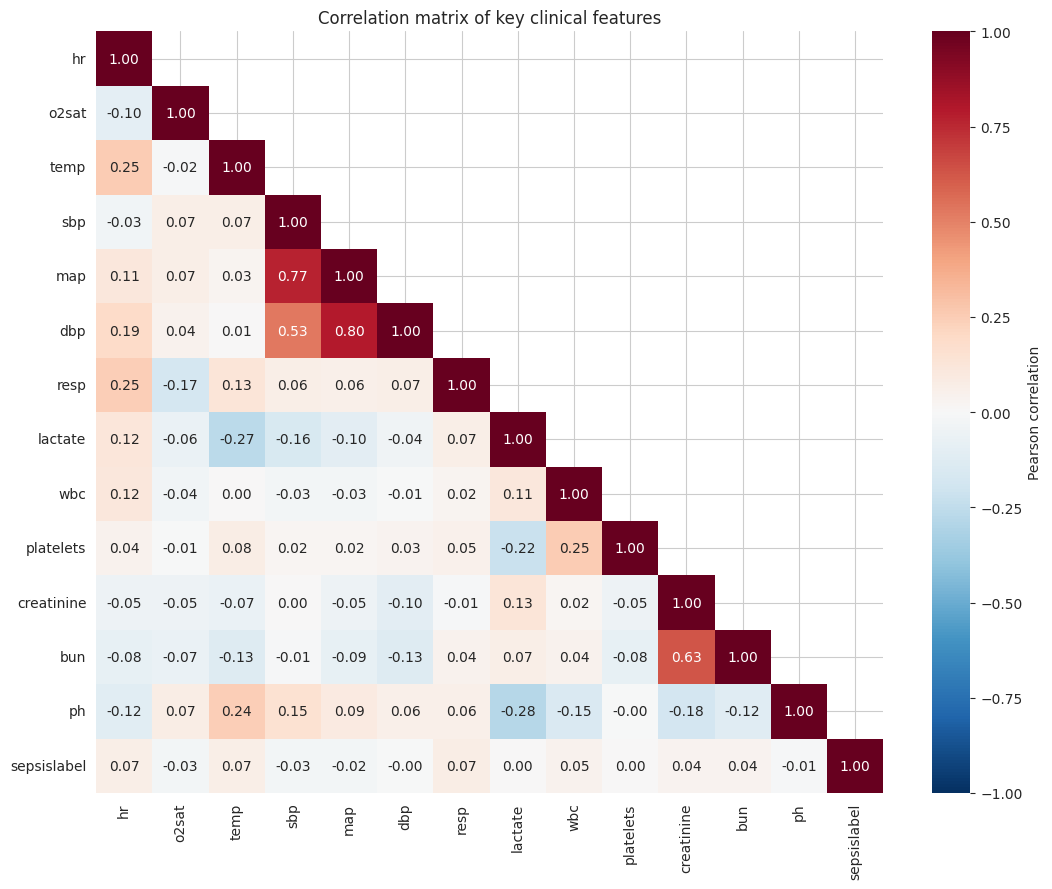


Top 10 features by absolute correlation with SepsisLabel:
  resp        : r=+0.074
  hr          : r=+0.069
  temp        : r=+0.067
  wbc         : r=+0.046
  bun         : r=+0.039
  creatinine  : r=+0.039
  o2sat       : r=-0.029
  sbp         : r=-0.025
  map         : r=-0.025
  ph          : r=-0.014


In [14]:
feature_cols = ['hr', 'o2sat', 'temp', 'sbp', 'map', 'dbp', 'resp',
                'lactate', 'wbc', 'platelets', 'creatinine', 'bun',
                'ph', 'sepsislabel']
available = [c for c in feature_cols if c in df.columns]
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation matrix of key clinical features')
plt.tight_layout()
plt.show()

print('\nTop 10 features by absolute correlation with SepsisLabel:')
sepsis_corr = corr['sepsislabel'].drop('sepsislabel').abs().sort_values(ascending=False)
for feat, val in sepsis_corr.head(10).items():
    signed = corr.loc[feat, 'sepsislabel']
    print(f'  {feat:12s}: r={signed:+.3f}')

### Patient phenotype clusters (KMeans + PCA)

We group patients by their average physiological profile to see whether distinct phenotypes exist and whether any cluster has elevated sepsis prevalence.

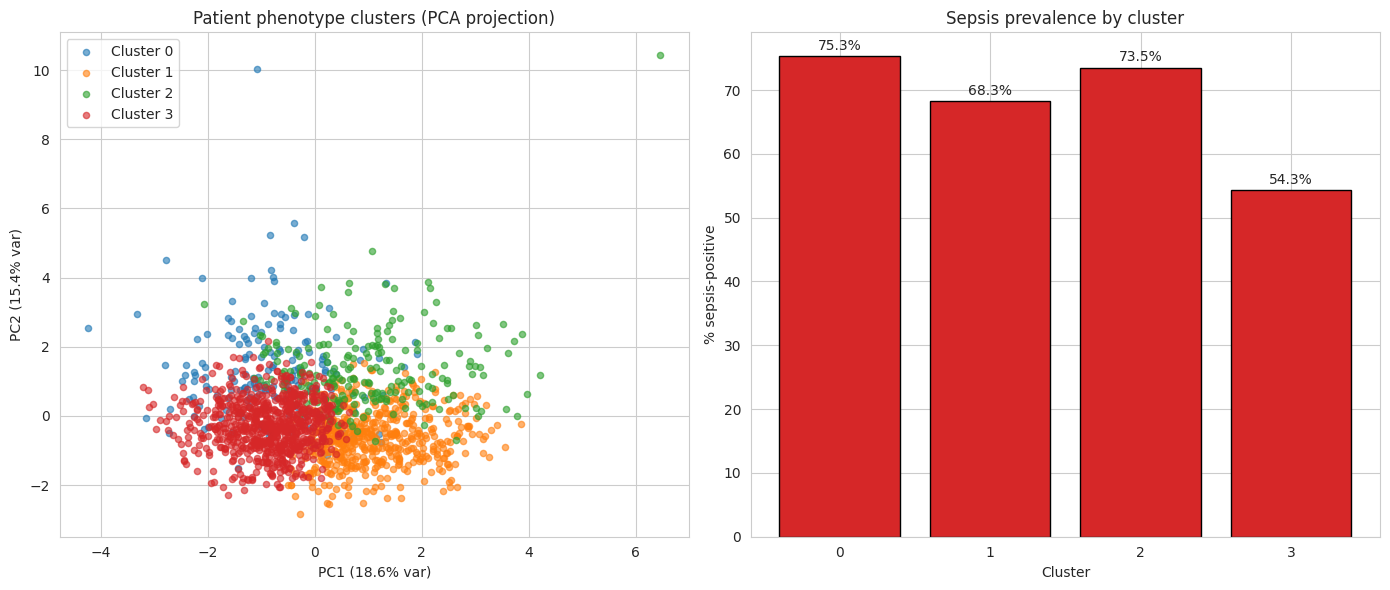


Cluster centroids (mean per cluster):


,hr,map,temp,resp,lactate,wbc,creatinine,platelets,age,sepsis_label
cluster,,,,,,,,,,
0.0,89.99,73.58,36.64,20.63,3.98,13.07,4.48,163.73,64.18,0.75
1.0,97.19,84.61,37.35,20.34,1.89,11.50,1.02,187.59,48.27,0.68
2.0,94.23,77.62,36.96,21.68,1.76,20.77,1.38,400.43,64.11,0.74
3.0,80.72,76.00,36.91,18.08,1.76,11.42,1.20,177.87,71.19,0.54


In [15]:
cluster_features = ['hr', 'map', 'temp', 'resp', 'lactate', 'wbc',
                    'creatinine', 'platelets']
available_cf = [c for c in cluster_features if c in df.columns]
patient_features = (df.groupby('patient_id')[available_cf]
                    .mean().reset_index())
patient_features = patient_features.merge(
    summary[['patient_id', 'age', 'sepsis_label', 'max_n_criteria']],
    on='patient_id'
)

X = patient_features[available_cf + ['age']].dropna()
patient_idx = X.index
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
patient_features.loc[patient_idx, 'cluster'] = clusters

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for c in range(4):
    mask_c = clusters == c
    axes[0].scatter(coords[mask_c, 0], coords[mask_c, 1],
                    label=f'Cluster {c}', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()
axes[0].set_title('Patient phenotype clusters (PCA projection)')

cluster_sepsis = (patient_features.dropna(subset=['cluster'])
                  .groupby('cluster')['sepsis_label'].mean() * 100)
bars = axes[1].bar(cluster_sepsis.index.astype(int).astype(str),
                   cluster_sepsis.values,
                   color='#d62728', edgecolor='black')
axes[1].set_ylabel('% sepsis-positive')
axes[1].set_xlabel('Cluster')
axes[1].set_title('Sepsis prevalence by cluster')
for bar, pct in zip(bars, cluster_sepsis.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\nCluster centroids (mean per cluster):')
cluster_summary = (patient_features.dropna(subset=['cluster'])
                   .groupby('cluster')[available_cf + ['age', 'sepsis_label']]
                   .mean().round(2))
cluster_summary